In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch
from PIL import Image

In [74]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Manchester United 3-2 Liverpool - Premier League 2025_2026 Live.html"
fotmob_matchId = 4813722

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)

In [75]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [76]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [77]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [78]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [79]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,relatedPlayerId,blockedX,blockedY,goalMouthZ,goalMouthY,isShot,isGoal,cardType,teamName,oppositionTeamName
0,2.932943e+09,3,0,0.0,26,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
1,2.932943e+09,3,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Liverpool
2,2.932943e+09,4,0,0.0,26,60.24,40.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
3,2.932943e+09,5,0,3.0,26,32.52,37.20,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
4,2.932943e+09,6,0,8.0,26,89.16,56.96,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1580,2.933046e+09,957,95,52.0,26,0.00,0.00,100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
1581,2.933049e+09,729,0,0.0,32,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Liverpool
1582,2.933046e+09,958,0,0.0,26,0.00,0.00,10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Liverpool,Man Utd
1583,2.932891e+09,2,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Man Utd,Liverpool


In [80]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,402184,31,Senne Lammens,GK,True,S. Lammens
1,353418,2,Diogo Dalot,DR,True,D. Dalot
2,517341,26,Ayden Heaven,DC,True,A. Heaven
3,99487,5,Harry Maguire,DC,True,H. Maguire
4,118244,23,Luke Shaw,DL,True,L. Shaw
5,88526,18,Casemiro,DMC,True,Casemiro
6,460260,37,Kobbie Mainoo,DMC,True,K. Mainoo
7,353377,19,Bryan Mbeumo,AMR,True,B. Mbeumo
8,123761,8,Bruno Fernandes,AMC,True,B. Fernandes
9,362758,10,Matheus Cunha,AML,True,M. Cunha


In [81]:
player="K. Mainoo"

In [82]:
df = df.merge(dfp, on='playerId', how='left')

In [83]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [84]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [85]:
# Save old values
x_old = df["x"].copy()
y_old = df["y"].copy()

# Transform
df["x"] = y_old
df["y"] = 120 - x_old

# Same for end coordinates
endx_old = df["endX"].copy()
endy_old = df["endY"].copy()

df["endX"] = endy_old
df["endY"] = 120 - endx_old

In [87]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
2,0,0.0,40.00,59.76,37.92,88.20,Liverpool,8.0,FW,D. Szoboszlai,NaN,NaN,NaN
3,0,3.0,37.20,87.48,56.96,30.84,Liverpool,28.0,GK,F. Woodman,NaN,NaN,NaN
4,0,8.0,56.96,30.84,23.76,4.44,Liverpool,18.0,AMC,C. Gakpo,NaN,NaN,NaN
6,0,29.0,39.92,102.84,27.36,93.48,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
7,0,30.0,27.36,93.48,24.96,98.16,Man Utd,18.0,DMC,Casemiro,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,95,25.0,80.00,101.28,68.96,68.28,Man Utd,23.0,DL,L. Shaw,NaN,NaN,NaN
1575,95,28.0,68.96,68.28,42.08,55.80,Man Utd,11.0,Sub,J. Zirkzee,NaN,NaN,NaN
1576,95,33.0,32.96,25.68,26.72,12.48,Man Utd,16.0,Sub,A. Diallo,NaN,NaN,NaN
1577,95,35.0,26.72,12.48,NaN,NaN,Man Utd,2.0,DR,D. Dalot,38.16,True,NaN


In [88]:
df["assist"] = df["isGoal"].shift(-1) == True

In [89]:
df.to_csv('players.csv', index=False)

In [90]:
df=df[df["shortName"]==player].reset_index()
df

,index,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal,assist
0,84,4,56.0,25.44,69.24,11.52,65.40,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
1,188,11,10.0,22.32,69.12,20.40,85.08,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
2,197,11,55.0,40.88,69.00,8.72,61.92,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
3,200,12,5.0,47.04,65.04,70.40,67.08,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
4,203,12,10.0,70.16,54.36,69.92,68.88,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
5,232,13,9.0,30.32,85.80,31.28,79.56,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
6,351,21,3.0,63.36,97.44,52.40,81.72,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
7,376,22,49.0,67.28,87.72,64.08,109.32,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
8,378,22,54.0,75.44,106.56,66.24,104.88,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False
9,403,24,25.0,67.76,90.96,61.76,96.24,Man Utd,37.0,DMC,K. Mainoo,NaN,NaN,NaN,False


In [91]:
response=requests.get("https://www.sofascore.com/football/match/liverpool-manchester-united/KU#id:14023939,tab:statistics")

In [92]:
soup=BeautifulSoup(response.text,"html.parser")

In [93]:
soup.select('g[cursor="pointer"]')

[]

In [94]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9,hi;q=0.8',
    'referer': 'https://www.sofascore.com/football/match/liverpool-manchester-united/KU',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36',
}

url='https://www.sofascore.com/api/v1/event/14023939/shotmap'

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [95]:
shots=response.json()

In [96]:
df_shots=pd.json_normalize(shots["shotmap"])

In [97]:
df_shots

,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,addedTime,...,draw.end.x,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,goalType
0,True,miss,assisted,right-foot,high,0.058522,0.000000,7191124,90,6.0,...,52.3,0,52.3,6.9,NaN,NaN,NaN,NaN,NaN,NaN
1,True,save,set-piece,right-foot,high-right,0.013325,0.250727,7191081,90,1.0,...,52.9,0,52.9,70.3,1.8,53.6,0.0,53.6,1.8,NaN
2,True,miss,assisted,left-foot,right,0.027255,0.000000,7191074,90,NaN,...,64.9,0,64.9,97.2,NaN,NaN,NaN,NaN,NaN,NaN
3,True,block,assisted,right-foot,low-centre,0.020967,0.000000,7191052,86,NaN,...,51.1,0,51.1,81.0,20.8,49.3,0.0,49.3,20.8,NaN
4,False,save,assisted,right-foot,low-left,0.041269,0.062909,7191039,84,NaN,...,48.1,0,48.1,96.8,2.0,49.1,0.0,49.1,2.0,NaN
5,False,miss,assisted,right-foot,right,0.048642,0.000000,7191020,82,NaN,...,64.2,0,64.2,88.9,NaN,NaN,NaN,NaN,NaN,NaN
6,True,goal,regular,right-foot,low-left,0.038989,0.193178,7190955,77,NaN,...,47.1,0,47.1,96.8,NaN,NaN,NaN,NaN,NaN,regular
7,False,block,free-kick,right-foot,low-centre,0.026094,0.000000,7190930,74,NaN,...,50.3,0,50.3,81.0,20.2,32.7,0.0,32.7,20.2,NaN
8,True,save,set-piece,head,low-centre,0.179230,0.042757,7190912,72,NaN,...,49.8,0,49.8,81.0,1.5,50.2,0.0,50.2,1.5,NaN
9,False,miss,corner,other,left,0.008017,0.000000,7191038,70,NaN,...,30.1,0,30.1,94.4,3.6,41.3,0.0,41.3,3.6,NaN


In [98]:
df_shots=df_shots.sort_values("time").reset_index()
df_shots

,index,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,...,draw.end.x,draw.end.y,draw.goal.x,draw.goal.y,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,goalType
0,28,True,goal,corner,left-foot,low-right,0.042315,0.362161,7190156,6,...,52.3,0,52.3,96.8,NaN,NaN,NaN,NaN,NaN,regular
1,29,True,block,corner,right-foot,low-centre,0.033035,0.000000,7190159,6,...,48.3,0,48.3,81.0,11.5,48.2,0.0,48.2,11.5,NaN
2,30,True,block,assisted,left-foot,low-centre,0.098263,0.000000,7190151,6,...,50.6,0,50.6,81.0,6.2,56.9,0.0,56.9,6.2,NaN
3,27,True,save,fast-break,left-foot,low-left,0.358398,0.452447,7190285,14,...,47.7,0,47.7,96.8,4.9,47.3,0.0,47.3,4.9,NaN
4,26,True,goal,regular,other,low-centre,0.790460,0.869337,7190293,14,...,51.8,0,51.8,98.7,NaN,NaN,NaN,NaN,NaN,regular
5,25,False,miss,assisted,right-foot,close-right,0.059669,0.000000,7190346,24,...,56.1,0,56.1,81.9,NaN,NaN,NaN,NaN,NaN,NaN
6,24,True,miss,assisted,right-foot,close-right,0.094015,0.000000,7190368,27,...,57.3,0,57.3,97.2,NaN,NaN,NaN,NaN,NaN,NaN
7,23,False,miss,assisted,right-foot,close-right,0.031598,0.000000,7190375,28,...,57.3,0,57.3,91.7,NaN,NaN,NaN,NaN,NaN,NaN
8,22,False,save,assisted,right-foot,low-centre,0.022488,0.014495,7190447,41,...,49.5,0,49.5,91.1,1.2,51.6,0.0,51.6,1.2,NaN
9,21,True,block,set-piece,right-foot,low-left,0.017992,0.000000,7190468,44,...,47.4,0,47.4,81.0,12.9,39.5,0.0,39.5,12.9,NaN


In [99]:
df_shots=df_shots[["isHome","shotType","xg","time","player.shortName","player.jerseyNumber","playerCoordinates.x","playerCoordinates.y",
        "goalMouthCoordinates.x","goalMouthCoordinates.y"]]

In [100]:
df_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
0,True,goal,0.042315,6,M. Cunha,10,15.3,45.7,0,47.7
1,True,block,0.033035,6,M. Cunha,10,19.4,48.1,0,51.7
2,True,block,0.098263,6,B. Šeško,30,7.0,57.7,0,49.4
3,True,save,0.358398,14,B. Šeško,30,8.4,45.9,0,52.3
4,True,goal,0.790460,14,B. Šeško,30,2.9,49.9,0,48.2
5,False,miss,0.059669,24,C. Gakpo,18,20.3,45.2,0,43.9
6,True,miss,0.094015,27,B. Fernandes,8,12.8,49.9,0,42.7
7,False,miss,0.031598,28,F. Wirtz,7,16.7,37.8,0,42.7
8,False,save,0.022488,41,R. Gravenberch,38,25.7,59.9,0,50.5
9,True,block,0.017992,44,M. Cunha,10,16.1,37.6,0,52.6


In [101]:
df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
df_shots["goalMouthCoordinates.x"]=df_shots["goalMouthCoordinates.x"]*1.2
df_shots["goalMouthCoordinates.y"]=df_shots["goalMouthCoordinates.y"]*0.8

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_18012\3668136620.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.x"]=df_shots["playerCoordinates.x"]*1.2
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_18012\3668136620.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shots["playerCoordinates.y"]=df_shots["playerCoordinates.y"]*0.8
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_18012\3668136620.py:3: SettingWithCopyWarning: 
A value is trying to be set on a c

In [102]:
for x in range(len(df_shots["playerCoordinates.x"])):
    if (df_shots["isHome"][x]==False):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
    if (df_shots["isHome"][x]==True):
        df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_18012\4112479664.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_shots["playerCoordinates.y"][x]=80 - df_shots["playerCoordinates.y"][x]
C:\Users\K Raghunandan\AppData\Local\Temp\ipy

In [103]:
df_shots=df_shots[df_shots["player.shortName"]==player]
df_shots

,isHome,shotType,xg,time,player.shortName,player.jerseyNumber,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.x,goalMouthCoordinates.y
24,True,goal,0.038989,77,K. Mainoo,37,22.56,40.16,0.0,42.32
27,True,block,0.020967,86,K. Mainoo,37,28.80,40.80,0.0,39.12


In [104]:
def create_shotmap(df, ax, color):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A',half=True)
    pitch.draw(ax=ax, constrained_layout=True, tight_layout=False)
    plt.gca().invert_yaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,45)

    for x in df.to_dict(orient='records'):
        if x['shotType'] == 'goal':
            pitch.plot((x["playerCoordinates.x"],x["goalMouthCoordinates.x"]),
                       (x["playerCoordinates.y"],x["goalMouthCoordinates.y"]),
                       color=color,
                       ax=ax,
                       alpha=0.7)
        pitch.scatter(
            x=x["playerCoordinates.x"], y=x["playerCoordinates.y"], ax=ax, 
            s=500 * x['xg'], 
            facecolor=color if x['shotType'] == 'goal' else "#EAEAEA", 
            edgecolors=color, alpha=0.7
        )

In [117]:
def create_heatmap(df,ax):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A')
    pitch.draw(ax=ax)
    plt.gca().invert_xaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,120)

    kde=sns.kdeplot(
    data=df, x="x", y="y",
    fill=True,
    shade_lowest=False,
    alpha=.2,
    bw_adjust=0.5,
    n_levels=7,
    cmap="hot"
    )

In [118]:
def create_passmap(df,ax,color1,color2):
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#EAEAEA', line_color='#3A3A3A')
    pitch.draw(ax=ax)
    plt.gca().invert_xaxis()

    ax.set_xlim(0,80)
    ax.set_ylim(0,120)

    for x in range(len(df["x"])):
        if (df["assist"][x]==True):
            plt.plot((df["x"][x],df["endX"][x]),(df["y"][x],df["endY"][x]),color=color2)
            plt.scatter(df["x"][x],df["y"][x],color=color2)

        if (df["assist"][x]==False):
            plt.plot((df["x"][x],df["endX"][x]),(df["y"][x],df["endY"][x]),color=color1)
            plt.scatter(df["x"][x],df["y"][x],color=color1)

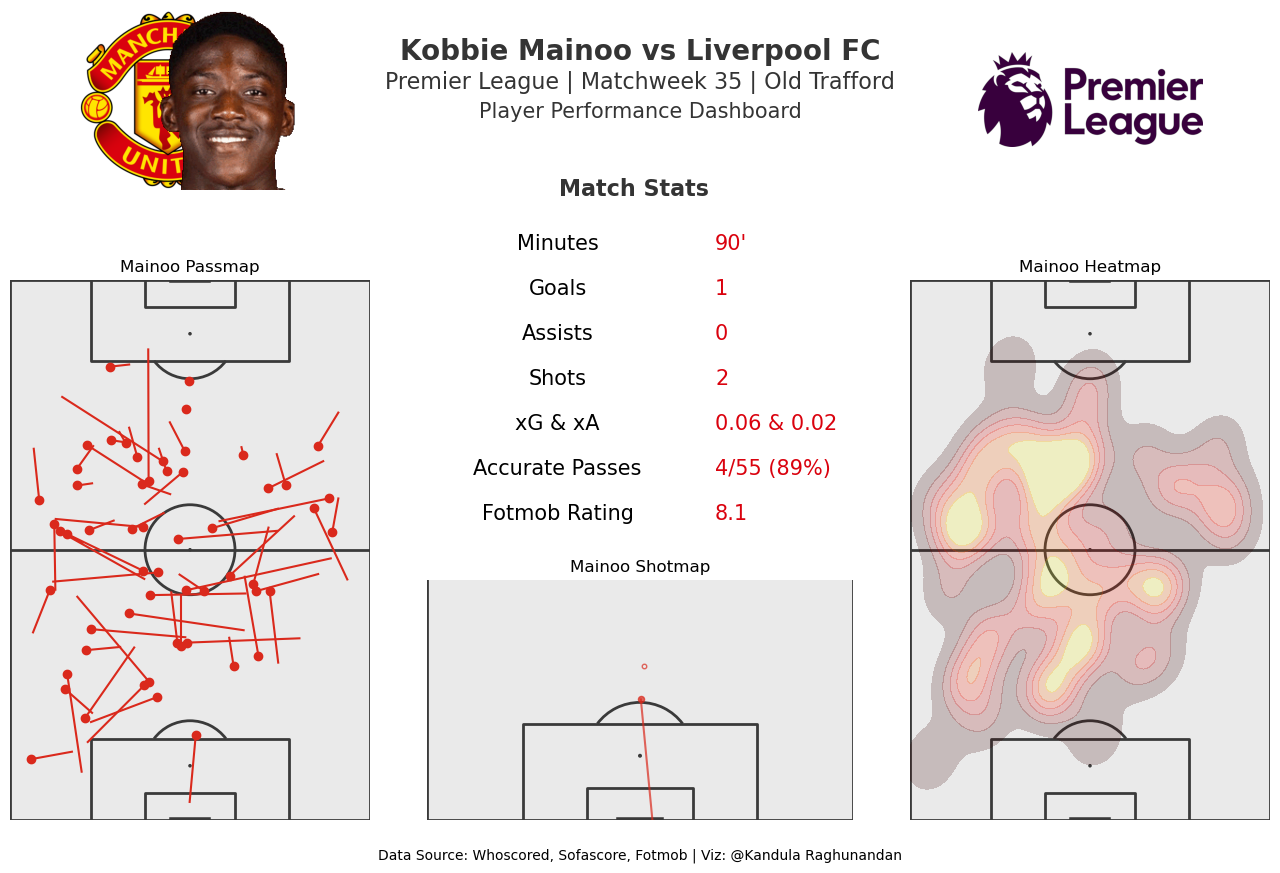

In [119]:
fig = plt.figure(figsize=(15,12))

ax1=fig.add_axes([0.21, 0.8, 0.15, 0.15])
team1_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png")
ax1.imshow(team1_img)
ax1.axis("off")

ax2=fig.add_axes([0.25, 0.8, 0.15, 0.15])
league_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Players/"+player+".png")
ax2.imshow(league_img)
ax2.axis("off")

ax3=fig.add_axes([0.825, 0.8, 0.15, 0.15])
league_img=Image.open("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")
ax3.imshow(league_img)
ax3.axis("off")

ax4=fig.add_axes([.45,.275,.3,.2])
create_shotmap(df_shots,ax4, "#DA291C")
ax4.set_title("Mainoo Shotmap")

plt.text(
    0.5, -0.15, "Data Source: Whoscored, Sofascore, Fotmob | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="black"
)

ax5=fig.add_axes([.15,.275,.3,.45])
create_passmap(df,ax5,"#DA291C","#FBE122")
ax5.invert_yaxis()
ax5.invert_xaxis()
ax5.set_title("Mainoo Passmap")

ax6=fig.add_axes([.75,.275,.3,.45])
create_heatmap(df,ax6)
ax6.invert_yaxis()
ax6.invert_xaxis()
ax6.set_title("Mainoo Heatmap")

ax7 = fig.add_axes([.5,.35,.3,.5])
ax7.set_facecolor("#f7f7f7")
ax7.axis("off")

ax7.text(0.32, 0.9, "Match Stats", ha="center", va="center",
         fontsize=16, fontweight="bold",color="#343434")

labels = ["Minutes", "Goals", "Assists", "Shots", "xG & xA", "Accurate Passes", "Fotmob Rating"]
y_positions = [0.8, 0.725, 0.65, 0.575, 0.5, 0.425,0.35]

vals = ["90'", 1,0, 2, "0.06 & 0.02", "4/55 (89%)", 8.1]

for label, y, n_val in zip(labels, y_positions, vals):
    ax7.text(0.15, y, label, ha="center", fontsize=15)
    ax7.text(0.5, y, str(n_val), ha="left", fontsize=15,color="#DA020E")

fig.text(0.6, 0.915, "Kobbie Mainoo vs Liverpool FC", fontsize=20, fontweight='bold', color='#343434', ha="center", va="center")
fig.text(0.6, 0.890, "Premier League | Matchweek 35 | Old Trafford", fontsize=16, color='#343434', ha="center", va="center")
fig.text(0.6, 0.865, "Player Performance Dashboard", fontsize=15, color='#343434', ha="center", va="center" )

fig.savefig("C:/Users/K Raghunandan/Analyst/Matches/Manchester United 3-2 Liverpool - Premier League 2025_2026 Live_files/New folder/match_dashboard.png", bbox_inches='tight')